# 🧹 Predictive Maintenance — Data Cleaning Pipeline

Notebook ini melakukan **Data Cleaning** lengkap untuk dataset Predictive Maintenance  
sebelum digunakan training **Classification & Regression Model**.

## Tahapan Cleaning:
| # | Tahap | Detail |
|---|-------|--------|
| 1 | **Load Data** | Baca raw CSV hasil EDA |
| 2 | **Hapus Kolom Tidak Relevan** | ID, kolom duplikat, konstanta |
| 3 | **Tipe Data & Format** | Datetime parse, downcast, encode target |
| 4 | **Missing Values** | Deteksi & imputasi strategis |
| 5 | **Duplikasi** | Deteksi & hapus |
| 6 | **Outlier** | IQR detection + Winsorizing |
| 7 | **Inkonsistensi Struktural** | Validasi range, konsistensi kalkulasi |
| 8 | **Encode Fitur Kategorikal** | Label encode / One-hot |
| 9 | **Class Imbalance Report** | Analisis & rekomendasi handling |
| 10 | **Simpan** | Export dataset bersih per use-case |

---
**Input :** `dataset/processed/predictive_maintenance_raw.csv`  
**Output:** `dataset/processed/pm_cleaned_*.csv` + `pm_cleaning_report.json`

---
## 📦 1. Import & Load Dataset

In [41]:
import os
import json
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
sns.set_palette('tab10')

# ── Path ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path(os.getcwd())
PROJECT_ROOT  = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_ROOT / 'dataset' / 'processed'

INPUT_FILE = PROCESSED_DIR / 'predictive_maintenance_raw.csv'
assert INPUT_FILE.exists(), f'❌ File tidak ada: {INPUT_FILE}\n   Jalankan dulu predictive_maintenance_eda.ipynb!'

print('✅ Import sukses!')
print(f'📂 Input: {INPUT_FILE}')

✅ Import sukses!
📂 Input: c:\AI\AI untuk Dashboard TA\New folder\dataset\processed\predictive_maintenance_raw.csv


In [42]:
df_raw = pd.read_csv(INPUT_FILE, parse_dates=['timestamp', 'record_date'])
ORIGINAL_SHAPE = df_raw.shape

print(f'✅ Dataset dimuat: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} kolom')
print(f'   Memori: {df_raw.memory_usage(deep=True).sum()/1024**2:.2f} MB')
print()
print('📋 Semua Kolom:')
for col in df_raw.columns:
    n_null = df_raw[col].isna().sum()
    print(f'   {col:<40} {str(df_raw[col].dtype):<15} null={n_null}')

df_raw.head(3)

✅ Dataset dimuat: 6,340 rows × 29 kolom
   Memori: 4.94 MB

📋 Semua Kolom:
   record_id                                str             null=0
   timestamp                                datetime64[us]  null=0
   record_date                              datetime64[us]  null=0
   machine_id                               str             null=0
   machine_name                             str             null=0
   line_id                                  str             null=0
   line_name                                str             null=0
   line_process_id                          str             null=0
   shift_id                                 str             null=0
   total_output                             int64           null=0
   avg_cycle_time_sec                       float64         null=0
   throughput_units_per_hour                float64         null=0
   shift_total_pass                         int64           null=0
   operating_seconds                        int64     

,record_id,timestamp,record_date,machine_id,machine_name,line_id,line_name,line_process_id,shift_id,total_output,avg_cycle_time_sec,throughput_units_per_hour,shift_total_pass,operating_seconds,oee,availability,performance,quality,total_produced,total_pass,total_reject,defect_rate,cum_running_hours,days_since_last_maintenance,corrective_wo_last_7d,preventive_wo_last_30d,hours_to_next_failure_event,failure_next_24h,maintenance_risk_level
0,471b5391-8fdf-453f-96a6-4a2a09ae3127,2026-02-01 11:39:00,2026-02-01,081f1278-fb94-44c6-a64f-edfe6a0596ca,Vision Inspection 01,0a4d2182-cf07-4dc3-b494-5cc84d4e97d9,Line A,fa41b074-82b3-4146-b745-ba968159798b,4a28e93f-183c-4b5f-9e90-703d80626680,850,24.8700,106.2500,4,28800,0.6635,1.0000,0.6635,1.0000,4.0000,4.0000,0.0000,0.0000,92.1900,NaN,0,0,148.9300,No,No Risk
1,4380fd75-f067-44d2-b7bf-8e0ba3b8258f,2026-02-01 18:21:00,2026-02-01,081f1278-fb94-44c6-a64f-edfe6a0596ca,Vision Inspection 01,0a4d2182-cf07-4dc3-b494-5cc84d4e97d9,Line A,fa41b074-82b3-4146-b745-ba968159798b,15b09269-ea40-4cc7-aeca-d0c85b53e3da,894,20.3400,111.7500,5,28800,0.6249,1.0000,0.6249,1.0000,5.0000,5.0000,0.0000,0.0000,92.1900,NaN,0,0,142.2300,No,No Risk
2,a81b99bc-f019-4879-a8be-aeefccbfa7fd,2026-02-02 13:28:00,2026-02-02,081f1278-fb94-44c6-a64f-edfe6a0596ca,Vision Inspection 01,0a4d2182-cf07-4dc3-b494-5cc84d4e97d9,Line A,fa41b074-82b3-4146-b745-ba968159798b,4a28e93f-183c-4b5f-9e90-703d80626680,1038,29.7100,129.7500,3,28800,1.0000,1.0000,1.0000,1.0000,3.0000,3.0000,0.0000,0.0000,92.1900,NaN,0,0,123.1100,No,No Risk


In [43]:
# ── Cleaning log ──────────────────────────────────────────────────────────────
cleaning_log = []

def log_step(step, desc, before_rows, after_rows, before_cols=None, after_cols=None, detail=''):
    entry = {
        'step'        : step,
        'desc'        : desc,
        'rows_before' : before_rows,
        'rows_after'  : after_rows,
        'rows_removed': before_rows - after_rows,
        'cols_before' : before_cols,
        'cols_after'  : after_cols,
        'cols_removed': (before_cols - after_cols) if (before_cols and after_cols) else None,
        'detail'      : detail,
    }
    cleaning_log.append(entry)
    icon = '✅' if (before_rows == after_rows and before_cols == after_cols) else '🔧'
    print(f'{icon} [{step}] {desc}')
    if before_rows != after_rows:
        print(f'   Rows: {before_rows:,} → {after_rows:,} (hapus {before_rows-after_rows:,})')
    if before_cols and after_cols and before_cols != after_cols:
        print(f'   Cols: {before_cols} → {after_cols} (hapus {before_cols-after_cols})')
    if detail:
        print(f'   Detail: {detail}')

df = df_raw.copy()
print(f'✅ Cleaning log siap. Dataset: {df.shape}')

✅ Cleaning log siap. Dataset: (6340, 29)


---
## 🗑️ 2. Hapus Kolom Tidak Relevan

In [44]:
before_cols = df.shape[1]
drop_reasons = {}

# (A) Kolom ID/UUID — tidak informatif untuk ML
ID_COLS = ['record_id', 'machine_id', 'line_id', 'line_process_id', 'shift_id']
for col in ID_COLS:
    if col in df.columns:
        drop_reasons[col] = 'ID/UUID — tidak informatif untuk ML'

# (B) Kolom tekstual yang sudah ada versi numeriknya
# machine_name, line_name → akan di-encode, tapi timestamp tidak perlu raw
# timestamp asli sudah ada record_date

# (C) Kolom dengan variance = 0 atau 1 unique value
for col in df.columns:
    if col not in drop_reasons and df[col].nunique() <= 1:
        drop_reasons[col] = f'Konstan (unique={df[col].nunique()})'

print(f'📋 Kolom yang Akan Dihapus ({len(drop_reasons)}):')
for col, reason in drop_reasons.items():
    print(f'   · {col:<40} → {reason}')

df.drop(columns=[c for c in drop_reasons if c in df.columns], inplace=True)
after_cols = df.shape[1]

log_step('Drop Kolom', 'Hapus kolom ID/UUID & konstanta',
         df.shape[0], df.shape[0], before_cols, after_cols,
         f'{len(drop_reasons)} kolom dihapus')

print(f'\n✅ Sisa kolom: {after_cols}')
print('   Kolom tersisa:', list(df.columns))

📋 Kolom yang Akan Dihapus (5):
   · record_id                                → ID/UUID — tidak informatif untuk ML
   · machine_id                               → ID/UUID — tidak informatif untuk ML
   · line_id                                  → ID/UUID — tidak informatif untuk ML
   · line_process_id                          → ID/UUID — tidak informatif untuk ML
   · shift_id                                 → ID/UUID — tidak informatif untuk ML
🔧 [Drop Kolom] Hapus kolom ID/UUID & konstanta
   Cols: 29 → 24 (hapus 5)
   Detail: 5 kolom dihapus

✅ Sisa kolom: 24
   Kolom tersisa: ['timestamp', 'record_date', 'machine_name', 'line_name', 'total_output', 'avg_cycle_time_sec', 'throughput_units_per_hour', 'shift_total_pass', 'operating_seconds', 'oee', 'availability', 'performance', 'quality', 'total_produced', 'total_pass', 'total_reject', 'defect_rate', 'cum_running_hours', 'days_since_last_maintenance', 'corrective_wo_last_7d', 'preventive_wo_last_30d', 'hours_to_next_failure_event', 

---
## 📅 3. Standarisasi Tipe Data & Ekstraksi Fitur Temporal

In [45]:
# ── 3.1 Ekstraksi Fitur Temporal dari timestamp & record_date ──────────────────
before_cols = df.shape[1]

for col in ['timestamp', 'record_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'timestamp' in df.columns:
    df['hour_of_day']   = df['timestamp'].dt.hour.astype('int8')
    df['day_of_week']   = df['timestamp'].dt.dayofweek.astype('int8')  # 0=Mon, 6=Sun
    df['week_of_year']  = df['timestamp'].dt.isocalendar().week.astype('int8')
    df['month']         = df['timestamp'].dt.month.astype('int8')
    df['is_weekend']    = (df['timestamp'].dt.dayofweek >= 5).astype('int8')
    df['is_night_shift'] = ((df['timestamp'].dt.hour >= 22) | (df['timestamp'].dt.hour < 6)).astype('int8')
    print('📅 Fitur temporal diekstrak dari timestamp:')
    print('   hour_of_day, day_of_week, week_of_year, month, is_weekend, is_night_shift')

# Hapus kolom datetime asli (sudah diekstrak)
df.drop(columns=[c for c in ['timestamp', 'record_date'] if c in df.columns], inplace=True)

after_cols = df.shape[1]
print(f'\n✅ Fitur bertambah dari {before_cols} → {after_cols} kolom (termasuk 6 fitur temporal baru)')

📅 Fitur temporal diekstrak dari timestamp:
   hour_of_day, day_of_week, week_of_year, month, is_weekend, is_night_shift

✅ Fitur bertambah dari 24 → 28 kolom (termasuk 6 fitur temporal baru)


In [46]:
# ── 3.2 Encode Kolom Kategorikal ──────────────────────────────────────────────
encode_log = {}

# machine_name → integer encoding (12 mesin)
if 'machine_name' in df.columns:
    machines = sorted(df['machine_name'].dropna().unique())
    machine_map = {m: i for i, m in enumerate(machines)}
    df['machine_encoded'] = df['machine_name'].map(machine_map).astype('int8')
    encode_log['machine_name'] = machine_map
    df.drop(columns=['machine_name'], inplace=True)
    print(f'🔢 machine_name → machine_encoded (0-{len(machines)-1})')
    for m, i in machine_map.items():
        print(f'   {i}: {m}')

# line_name → integer encoding (4 line)
if 'line_name' in df.columns:
    lines = sorted(df['line_name'].dropna().unique())
    line_map = {l: i for i, l in enumerate(lines)}
    df['line_encoded'] = df['line_name'].map(line_map).astype('int8')
    encode_log['line_name'] = line_map
    df.drop(columns=['line_name'], inplace=True)
    print(f'\n🔢 line_name → line_encoded (0-{len(lines)-1})')
    for l, i in line_map.items():
        print(f'   {i}: {l}')

print(f'\n✅ Shape setelah encoding: {df.shape}')

🔢 machine_name → machine_encoded (0-11)
   0: Assembly Robot 04
   1: CNC Milling 05
   2: Conveyor & Sorter 10
   3: Injection Molding 07
   4: Injection Molding 08
   5: Packaging Machine 09
   6: SMT Placement 12
   7: Torque Screwdriver Cell 02
   8: Torque Screwdriver Cell 06
   9: Torque Screwdriver Cell 11
   10: Vision Inspection 01
   11: Wire Bonding 03

🔢 line_name → line_encoded (0-3)
   0: Line A
   1: Line B
   2: Line C
   3: Line D

✅ Shape setelah encoding: (6340, 28)


In [47]:
# ── 3.3 Encode Target Variables ───────────────────────────────────────────────
# Simpan versi string asli sebelum di-encode
TARGET_BINARY    = 'failure_next_24h'
TARGET_MULTICLASS = 'maintenance_risk_level'
TARGET_REGRESSION = 'hours_to_next_failure_event'

# Binary: Yes=1, No=0
if TARGET_BINARY in df.columns:
    df['failure_binary'] = (df[TARGET_BINARY].str.strip().str.lower() == 'yes').astype('int8')
    print(f'🎯 {TARGET_BINARY} → failure_binary (0/1)')
    print(f'   No(0) : {(df["failure_binary"]==0).sum():,}')
    print(f'   Yes(1): {(df["failure_binary"]==1).sum():,}')

# Multi-class: No Risk=0, Low=1, Medium=2, High=3
RISK_ORDER = ['No Risk', 'Low Risk', 'Medium Risk', 'High Risk']
RISK_MAP   = {r: i for i, r in enumerate(RISK_ORDER)}
if TARGET_MULTICLASS in df.columns:
    df['risk_level_encoded'] = df[TARGET_MULTICLASS].map(RISK_MAP).astype('Int8')  # Int8 supports NA
    encode_log['maintenance_risk_level'] = RISK_MAP
    print(f'\n🎯 {TARGET_MULTICLASS} → risk_level_encoded (0-3)')
    for r, i in RISK_MAP.items():
        n = (df['risk_level_encoded'] == i).sum()
        print(f'   {i}: {r:<15} → {n:,} records')

print(f'\n✅ Target encoding selesai. Shape: {df.shape}')

🎯 failure_next_24h → failure_binary (0/1)
   No(0) : 5,090
   Yes(1): 1,250

🎯 maintenance_risk_level → risk_level_encoded (0-3)
   0: No Risk         → 5,090 records
   1: Low Risk        → 256 records
   2: Medium Risk     → 296 records
   3: High Risk       → 698 records

✅ Target encoding selesai. Shape: (6340, 30)


In [48]:
# ── 3.4 Optimasi Tipe Data Numerik ────────────────────────────────────────────
int_cols   = df.select_dtypes(include='int64').columns
float_cols = df.select_dtypes(include='float64').columns

for col in int_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

HIGH_PRECISION = ['oee', 'availability', 'performance', 'quality',
                   'defect_rate', 'hours_to_next_failure_event']
for col in float_cols:
    if col not in HIGH_PRECISION:
        df[col] = df[col].astype('float32')

before_mem = df_raw.memory_usage(deep=True).sum() / 1024**2
after_mem  = df.memory_usage(deep=True).sum() / 1024**2
print(f'✅ Optimasi dtype selesai')
print(f'   Memori sebelum : {before_mem:.2f} MB')
print(f'   Memori sesudah : {after_mem:.2f} MB  (-{(before_mem-after_mem):.2f} MB)')

log_step('Tipe Data', 'Encoding & optimasi tipe data', df.shape[0], df.shape[0],
         detail='datetime ekstrak 6 fitur temporal, encode machine/line/target')

✅ Optimasi dtype selesai
   Memori sebelum : 4.94 MB
   Memori sesudah : 1.22 MB  (-3.72 MB)
✅ [Tipe Data] Encoding & optimasi tipe data
   Detail: datetime ekstrak 6 fitur temporal, encode machine/line/target


---
## 🕳️ 4. Penanganan Missing Values

📋 Kolom dengan Missing Values (6 kolom):
                             count    pct    dtype
days_since_last_maintenance    264 4.1600  float32
hours_to_next_failure_event    123 1.9400  float64
defect_rate                     63 0.9900  float64
total_produced                  45 0.7100  float32
total_pass                      45 0.7100  float32
total_reject                    45 0.7100  float32



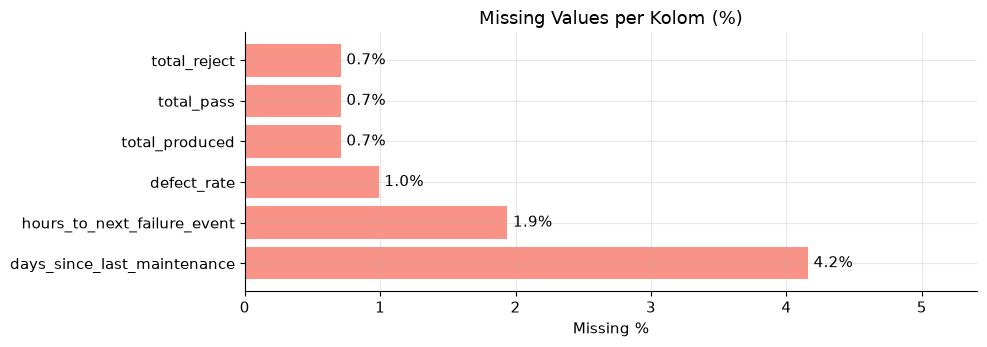

In [49]:
# ── 4.1 Deteksi ───────────────────────────────────────────────────────────────
null_df = pd.DataFrame({
    'count'  : df.isnull().sum(),
    'pct'    : (df.isnull().mean() * 100).round(2),
    'dtype'  : df.dtypes,
}).query('count > 0').sort_values('count', ascending=False)

print(f'📋 Kolom dengan Missing Values ({len(null_df)} kolom):')
if len(null_df):
    print(null_df.to_string())
    print()
    # Visualisasi
    fig, ax = plt.subplots(figsize=(10, max(3, len(null_df)*0.6)))
    bars = ax.barh(null_df.index, null_df['pct'], color='salmon', alpha=0.85)
    ax.bar_label(bars, labels=[f'{v:.1f}%' for v in null_df['pct']], padding=4)
    ax.set_title('Missing Values per Kolom (%)')
    ax.set_xlabel('Missing %')
    ax.set_xlim(0, null_df['pct'].max() * 1.3)
    plt.tight_layout()
    plt.show()
else:
    print('   ✅ Tidak ada missing values!')

In [50]:
# ── 4.2 Strategi Imputasi ─────────────────────────────────────────────────────
#
# Strategi per kolom:
# • total_produced, total_pass, total_reject → median per machine_encoded
# • defect_rate → recalculate dari total_reject / total_produced
# • days_since_last_maintenance → 0 (mesin baru, belum pernah maintenance)
# • hours_to_next_failure_event → dibiarkan NaN untuk rows yang di luar window
#   (hanya untuk dataset regression, bukan classification)
#
imputation_report = {}

# (A) total_produced, total_pass, total_reject — imputasi median per mesin
for col in ['total_produced', 'total_pass', 'total_reject']:
    if col in df.columns and df[col].isna().sum() > 0:
        n_before = df[col].isna().sum()
        if 'machine_encoded' in df.columns:
            df[col] = df.groupby('machine_encoded')[col].transform(
                lambda x: x.fillna(x.median())
            )
        df[col] = df[col].fillna(df[col].median())
        n_after = df[col].isna().sum()
        imputation_report[col] = f'Median per mesin ({n_before} → {n_after} null)'
        print(f'✅ {col}: {n_before} → {n_after} null (median per mesin)')

# (B) defect_rate — recalculate
if 'defect_rate' in df.columns:
    n_before = df['defect_rate'].isna().sum()
    if all(c in df.columns for c in ['total_reject', 'total_produced']):
        mask = df['defect_rate'].isna() & df['total_produced'].notna()
        df.loc[mask, 'defect_rate'] = (
            df.loc[mask, 'total_reject'] / df.loc[mask, 'total_produced'].replace(0, np.nan)
        ).fillna(0)
    df['defect_rate'].fillna(0, inplace=True)
    n_after = df['defect_rate'].isna().sum()
    imputation_report['defect_rate'] = f'Recalculate total_reject/total_produced ({n_before} → {n_after} null)'
    print(f'✅ defect_rate: {n_before} → {n_after} null (recalculated)')

# (C) days_since_last_maintenance → 0 (baru pertama kali)
if 'days_since_last_maintenance' in df.columns and df['days_since_last_maintenance'].isna().sum() > 0:
    n_before = df['days_since_last_maintenance'].isna().sum()
    df['days_since_last_maintenance'].fillna(0.0, inplace=True)
    imputation_report['days_since_last_maintenance'] = f'Fill 0 (mesin baru, belum pernah maintenance) [{n_before} rows]'
    print(f'✅ days_since_last_maintenance: {n_before} null → 0 (mesin baru)')

# (D) hours_to_next_failure_event — biarkan NaN (hanya untuk regression dataset)
if 'hours_to_next_failure_event' in df.columns:
    n_null = df['hours_to_next_failure_event'].isna().sum()
    imputation_report['hours_to_next_failure_event'] = (
        f'Dibiarkan NaN ({n_null} rows) — hanya valid untuk regression dataset, '
        f'rows ini di-drop saat membuat pm_cleaned_regression.csv'
    )
    print(f'ℹ️  hours_to_next_failure_event: {n_null} null dibiarkan (akan di-drop untuk regression only)')

total_null_after = df.drop(columns=['hours_to_next_failure_event'], errors='ignore').isnull().sum().sum()
print(f'\n✅ Total missing (excl. hours_to_next_failure): {total_null_after}')
log_step('Missing Values', 'Imputasi missing values', df.shape[0], df.shape[0],
         detail=str(imputation_report))

✅ total_produced: 45 → 0 null (median per mesin)
✅ total_pass: 45 → 0 null (median per mesin)
✅ total_reject: 45 → 0 null (median per mesin)
✅ defect_rate: 63 → 0 null (recalculated)
✅ days_since_last_maintenance: 264 null → 0 (mesin baru)
ℹ️  hours_to_next_failure_event: 123 null dibiarkan (akan di-drop untuk regression only)

✅ Total missing (excl. hours_to_next_failure): 264
✅ [Missing Values] Imputasi missing values
   Detail: {'total_produced': 'Median per mesin (45 → 0 null)', 'total_pass': 'Median per mesin (45 → 0 null)', 'total_reject': 'Median per mesin (45 → 0 null)', 'defect_rate': 'Recalculate total_reject/total_produced (63 → 0 null)', 'days_since_last_maintenance': 'Fill 0 (mesin baru, belum pernah maintenance) [264 rows]', 'hours_to_next_failure_event': 'Dibiarkan NaN (123 rows) — hanya valid untuk regression dataset, rows ini di-drop saat membuat pm_cleaned_regression.csv'}


---
## 👯 5. Penanganan Duplikasi

In [51]:
n_before = len(df)
n_exact  = df.duplicated().sum()
print(f'📋 Duplikat terdeteksi: {n_exact:,}')

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
n_after = len(df)

log_step('Duplikasi', 'Hapus baris duplikat', n_before, n_after,
         detail=f'{n_before - n_after} baris dihapus')
print(f'✅ Dataset setelah deduplikasi: {df.shape}')
assert df.duplicated().sum() == 0, '❌ Masih ada duplikat!'
print('✅ Verifikasi: 0 duplikat tersisa.')

📋 Duplikat terdeteksi: 0
✅ [Duplikasi] Hapus baris duplikat
   Detail: 0 baris dihapus
✅ Dataset setelah deduplikasi: (6340, 30)
✅ Verifikasi: 0 duplikat tersisa.


---
## 📊 6. Deteksi & Penanganan Outlier

In [52]:
# ── 6.1 Deteksi Outlier (IQR Method) ─────────────────────────────────────────
SKIP_OUTLIER = [
    # Kolom boolean/flag
    'is_weekend', 'is_night_shift', 'failure_binary', 'risk_level_encoded',
    # Kolom encoding
    'machine_encoded', 'line_encoded',
    # Kolom temporal ordinal
    'hour_of_day', 'day_of_week', 'week_of_year', 'month',
    # Kolom WO count (nilai ekstrem bisa valid)
    'corrective_wo_last_7d', 'preventive_wo_last_30d',
    # Regression target
    'hours_to_next_failure_event',
]

NUM_COLS = [c for c in df.select_dtypes(include='number').columns
             if c not in SKIP_OUTLIER]

outlier_report = {}
for col in NUM_COLS:
    s = df[col].dropna()
    if len(s) == 0: continue
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lo) | (s > hi)).sum()
    z     = np.abs(stats.zscore(s, nan_policy='omit'))
    n_z   = (z > 3).sum()
    outlier_report[col] = {
        'Q1': round(float(Q1),4), 'Q3': round(float(Q3),4),
        'lower': round(float(lo),4), 'upper': round(float(hi),4),
        'n_iqr': int(n_out), 'pct_iqr': round(n_out/len(s)*100,2),
        'n_z3':  int(n_z),  'pct_z3':  round(n_z/len(s)*100,2),
    }

out_df = pd.DataFrame(outlier_report).T.sort_values('pct_iqr', ascending=False)
print('📋 Laporan Outlier (IQR Method):')
print(f'   {"Kolom":<35} {"IQR Out":>9} {"IQR %":>7} {"Z>3 Out":>9} {"Z>3 %":>7}')
print('   ' + '-'*72)
for col, row in out_df.iterrows():
    flag = ' ⚠️' if row['pct_iqr'] > 5 else ''
    print(f'   {col:<35} {int(row["n_iqr"]):>9,} {row["pct_iqr"]:>6.1f}%'
          f' {int(row["n_z3"]):>9,} {row["pct_z3"]:>6.1f}%{flag}')

📋 Laporan Outlier (IQR Method):
   Kolom                                 IQR Out   IQR %   Z>3 Out   Z>3 %
   ------------------------------------------------------------------------
   quality                                   943   14.9%       127    2.0% ⚠️
   total_reject                              918   14.5%        74    1.2% ⚠️
   defect_rate                               918   14.5%       123    1.9% ⚠️
   availability                              819   12.9%       128    2.0% ⚠️
   operating_seconds                         818   12.9%       128    2.0% ⚠️
   days_since_last_maintenance               388    6.4%       163    2.7% ⚠️
   throughput_units_per_hour                  32    0.5%        32    0.5%
   total_produced                              7    0.1%         7    0.1%
   shift_total_pass                            7    0.1%         7    0.1%
   total_pass                                  4    0.1%         4    0.1%
   total_output                                0 

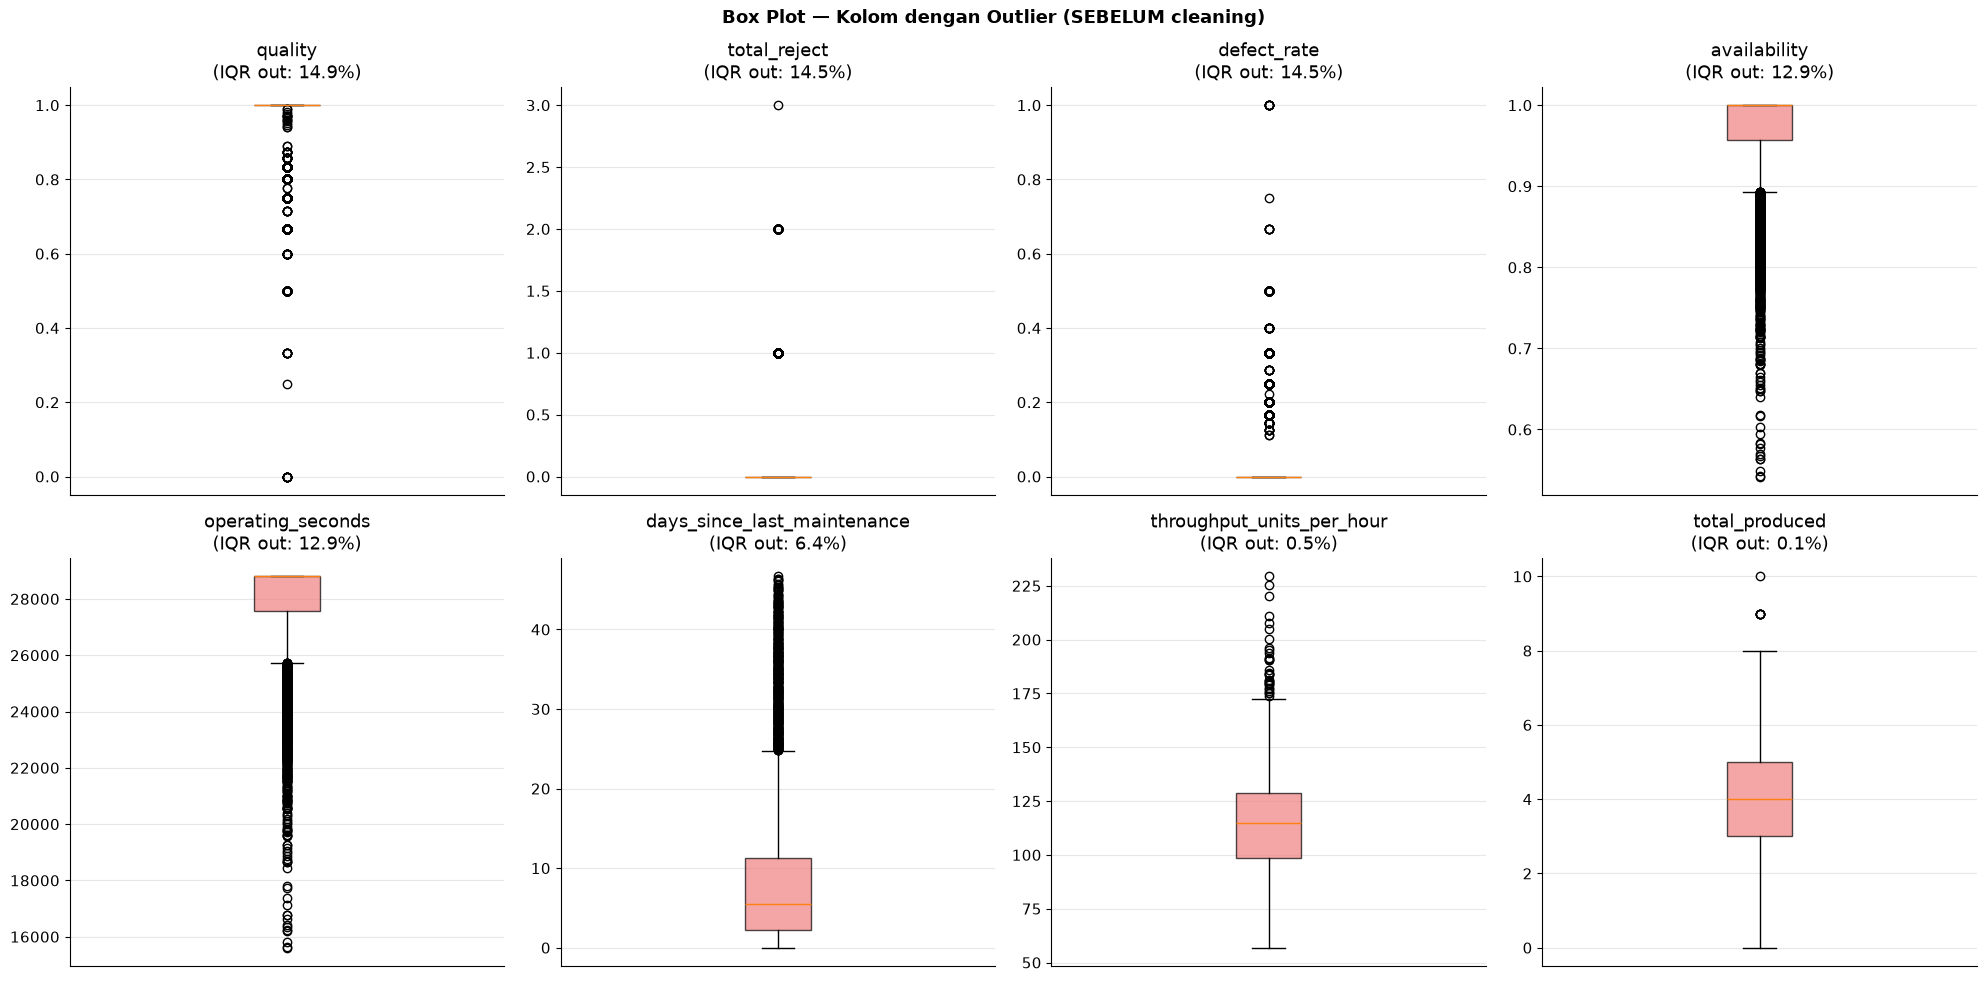

In [53]:
# ── 6.2 Visualisasi Top Outlier ───────────────────────────────────────────────
top_out = out_df[out_df['pct_iqr'] > 0].head(8).index.tolist()

if top_out:
    n, cpr = len(top_out), 4
    nrows  = (n + cpr - 1) // cpr
    fig, axes = plt.subplots(nrows, cpr, figsize=(20, 5*nrows))
    axes = axes.flat
    for ax, col in zip(axes, top_out):
        data = df[col].dropna()
        ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7))
        pct = out_df.loc[col, 'pct_iqr']
        ax.set_title(f'{col}\n(IQR out: {pct:.1f}%)')
        ax.set_xticks([])
    for ax in list(axes)[len(top_out):]:
        ax.set_visible(False)
    plt.suptitle('Box Plot — Kolom dengan Outlier (SEBELUM cleaning)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [54]:
# ── 6.3 Winsorizing (Capping) ─────────────────────────────────────────────────
#
# Strategi: clip ke batas IQR [Q1-1.5*IQR, Q3+1.5*IQR]
# Tidak hapus baris agar tidak mengurangi data yang sudah terbatas
#
# Logical bounds tambahan:
LOGICAL_BOUNDS = {
    'oee'                       : (0.0, 1.0),
    'availability'              : (0.0, 1.0),
    'performance'               : (0.0, 1.0),
    'quality'                   : (0.0, 1.0),
    'defect_rate'               : (0.0, 1.0),
    'total_output'              : (0,   None),
    'total_produced'            : (0,   None),
    'total_pass'                : (0,   None),
    'total_reject'              : (0,   None),
    'cum_running_hours'         : (0,   None),
    'days_since_last_maintenance': (0,  None),
    'avg_cycle_time_sec'        : (0,   None),
    'throughput_units_per_hour' : (0,   None),
    'operating_seconds'         : (0,   28800),  # Max 8 jam shift
    'shift_total_pass'          : (0,   None),
}

winsor_log = []

for col in NUM_COLS:
    if col not in df.columns: continue
    pct_out = out_df.loc[col, 'pct_iqr'] if col in out_df.index else 0
    if pct_out == 0: continue

    Q1   = df[col].quantile(0.25)
    Q3   = df[col].quantile(0.75)
    IQR  = Q3 - Q1
    lo   = Q1 - 1.5 * IQR
    hi   = Q3 + 1.5 * IQR

    # Terapkan batas logis
    if col in LOGICAL_BOUNDS:
        lb, ub = LOGICAL_BOUNDS[col]
        if lb is not None: lo = max(lo, lb)
        if ub is not None: hi = min(hi, ub)

    n_low  = (df[col] < lo).sum()
    n_high = (df[col] > hi).sum()
    if n_low + n_high > 0:
        df[col] = df[col].clip(lower=lo, upper=hi)
        winsor_log.append({'kolom': col, 'lower': round(lo,4), 'upper': round(hi,4),
                            'n_capped': int(n_low+n_high),
                            'pct': round((n_low+n_high)/len(df)*100,2)})

print('📋 Winsorizing Report:')
if winsor_log:
    wdf = pd.DataFrame(winsor_log)
    print(wdf.to_string(index=False))
else:
    print('   ✅ Tidak ada nilai yang perlu di-cap.')

log_step('Outlier', 'Winsorizing IQR capping', df.shape[0], df.shape[0],
         detail=f'{len(winsor_log)} kolom di-cap')

📋 Winsorizing Report:
                      kolom      lower      upper  n_capped     pct
  throughput_units_per_hour    53.5513   173.6612        32  0.5000
           shift_total_pass     0.0000     8.0000         7  0.1100
          operating_seconds 25715.6250 28800.0000       818 12.9000
               availability     0.8929     1.0000       819 12.9200
                    quality     1.0000     1.0000       943 14.8700
             total_produced     0.0000     8.0000         7  0.1100
                 total_pass     0.0000     8.0000         4  0.0600
               total_reject     0.0000     0.0000       918 14.4800
                defect_rate     0.0000     0.0000       918 14.4800
days_since_last_maintenance     0.0000    24.7837       388  6.1200
✅ [Outlier] Winsorizing IQR capping
   Detail: 10 kolom di-cap


---
## 🔧 7. Perbaiki Inkonsistensi Struktural

In [55]:
# ── 7.1 Validasi Range Logis ──────────────────────────────────────────────────
violations = {}
for col, (lo, hi) in LOGICAL_BOUNDS.items():
    if col not in df.columns: continue
    v_low  = (df[col] < lo).sum() if lo is not None else 0
    v_high = (df[col] > hi).sum() if hi is not None else 0
    if v_low > 0 or v_high > 0:
        violations[col] = {'below': int(v_low), 'above': int(v_high)}
        df[col] = df[col].clip(
            lower=lo if lo is not None else -np.inf,
            upper=hi if hi is not None else  np.inf
        )
        print(f'⚠️  {col}: {v_low} < {lo}, {v_high} > {hi} → di-clip')
    else:
        print(f'✅ {col}: OK [{lo}, {hi}]')

if not violations:
    print('\n✅ Tidak ada pelanggaran range logis.')

✅ oee: OK [0.0, 1.0]
✅ availability: OK [0.0, 1.0]
✅ performance: OK [0.0, 1.0]
✅ quality: OK [0.0, 1.0]
✅ defect_rate: OK [0.0, 1.0]
✅ total_output: OK [0, None]
✅ total_produced: OK [0, None]
✅ total_pass: OK [0, None]
✅ total_reject: OK [0, None]
✅ cum_running_hours: OK [0, None]
✅ days_since_last_maintenance: OK [0, None]
✅ avg_cycle_time_sec: OK [0, None]
✅ throughput_units_per_hour: OK [0, None]
✅ operating_seconds: OK [0, 28800]
✅ shift_total_pass: OK [0, None]

✅ Tidak ada pelanggaran range logis.


In [56]:
# ── 7.2 Konsistensi Kalkulasi Internal ────────────────────────────────────────
# total_pass + total_reject ≤ total_produced
if all(c in df.columns for c in ['total_pass', 'total_reject', 'total_produced']):
    df['total_pass']    = df['total_pass'].astype(float)
    df['total_reject']  = df['total_reject'].astype(float)
    df['total_produced']= df['total_produced'].astype(float)

    incon = (df['total_pass'] + df['total_reject']) > df['total_produced']
    n_incon = incon.sum()
    if n_incon:
        df.loc[incon, 'total_reject'] = (
            df.loc[incon, 'total_produced'] - df.loc[incon, 'total_pass']
        ).clip(lower=0)
        print(f'🔧 {n_incon} inkonsistensi total_pass+total_reject > total_produced diperbaiki')
    else:
        print('✅ total_pass + total_reject ≤ total_produced: OK')

# Recalculate defect_rate
if all(c in df.columns for c in ['defect_rate', 'total_reject', 'total_produced']):
    df['defect_rate'] = (
        df['total_reject'] / df['total_produced'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)
    print('✅ defect_rate di-recalculate dari total_reject / total_produced')

# OEE = Availability × Performance × Quality
if all(c in df.columns for c in ['oee', 'availability', 'performance', 'quality']):
    expected_oee = df['availability'] * df['performance'] * df['quality']
    oee_diff = (df['oee'] - expected_oee).abs()
    large_diff = (oee_diff > 0.05).sum()
    if large_diff > 0:
        print(f'⚠️  {large_diff} baris OEE ≠ Avail×Perf×Quality (diff > 0.05) — normalisasi')
    else:
        print(f'✅ OEE = Availability × Performance × Quality: konsisten ({oee_diff.mean():.4f} avg diff)')

log_step('Konsistensi', 'Validasi range & konsistensi kalkulasi', df.shape[0], df.shape[0],
         detail=f'{len(violations)} range violations, {n_incon if "n_incon" in dir() else 0} pass+reject violations')

✅ total_pass + total_reject ≤ total_produced: OK
✅ defect_rate di-recalculate dari total_reject / total_produced
⚠️  1205 baris OEE ≠ Avail×Perf×Quality (diff > 0.05) — normalisasi
✅ [Konsistensi] Validasi range & konsistensi kalkulasi
   Detail: 0 range violations, 0 pass+reject violations


---
## ✅ 8. Validasi Dataset Bersih

In [57]:
print('=' * 65)
print('  VALIDASI AKHIR — PREDICTIVE MAINTENANCE CLEANED')
print('=' * 65)

# Drop kolom string target asli (sudah di-encode)
STRING_TARGET_COLS = [TARGET_BINARY, TARGET_MULTICLASS]
df.drop(columns=[c for c in STRING_TARGET_COLS if c in df.columns], inplace=True)

checks = {}

# 1. Missing (exc. regression target)
null_excl = df.drop(columns=[TARGET_REGRESSION], errors='ignore').isnull().sum().sum()
checks['Missing values (excl. reg target)'] = '✅ PASS' if null_excl == 0 else f'❌ FAIL ({null_excl})'

# 2. Duplikat
n_dup = df.duplicated().sum()
checks['Duplikat'] = '✅ PASS' if n_dup == 0 else f'❌ FAIL ({n_dup})'

# 3. Infinite values
numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] > 0:
    n_inf = np.isinf(numeric_df.to_numpy(dtype='float64')).sum()
else:
    n_inf = 0

checks['Infinite values'] = (
    '✅ PASS' if n_inf == 0 else f'❌ FAIL ({n_inf})'
)

# 4. Row count
checks['Row count'] = f'✅ {len(df):,} rows ({len(df)/ORIGINAL_SHAPE[0]*100:.1f}% retained)'

# 5. Target encoded present
checks['failure_binary encoded']     = '✅ PASS' if 'failure_binary' in df.columns else '❌ MISSING'
checks['risk_level_encoded present'] = '✅ PASS' if 'risk_level_encoded' in df.columns else '❌ MISSING'

for check, status in checks.items():
    print(f'   {check:<45} : {status}')

print()
print(f'   Shape awal   : {ORIGINAL_SHAPE[0]:,} rows × {ORIGINAL_SHAPE[1]} kolom')
print(f'   Shape bersih : {df.shape[0]:,} rows × {df.shape[1]} kolom')

print('\n📋 Semua Kolom Dataset Bersih:')
for i, col in enumerate(df.columns, 1):
    null_n = df[col].isna().sum()
    null_s = f' [null={null_n}]' if null_n > 0 else ''
    print(f'   {i:>2}. {col:<40} {str(df[col].dtype)}{null_s}')
print('=' * 65)

  VALIDASI AKHIR — PREDICTIVE MAINTENANCE CLEANED
   Missing values (excl. reg target)             : ❌ FAIL (264)
   Duplikat                                      : ✅ PASS
   Infinite values                               : ✅ PASS
   Row count                                     : ✅ 6,340 rows (100.0% retained)
   failure_binary encoded                        : ✅ PASS
   risk_level_encoded present                    : ✅ PASS

   Shape awal   : 6,340 rows × 29 kolom
   Shape bersih : 6,340 rows × 28 kolom

📋 Semua Kolom Dataset Bersih:
    1. total_output                             int16
    2. avg_cycle_time_sec                       float32
    3. throughput_units_per_hour                float32
    4. shift_total_pass                         int8
    5. operating_seconds                        float64
    6. oee                                      float64
    7. availability                             float64
    8. performance                              float64
    9. quality   

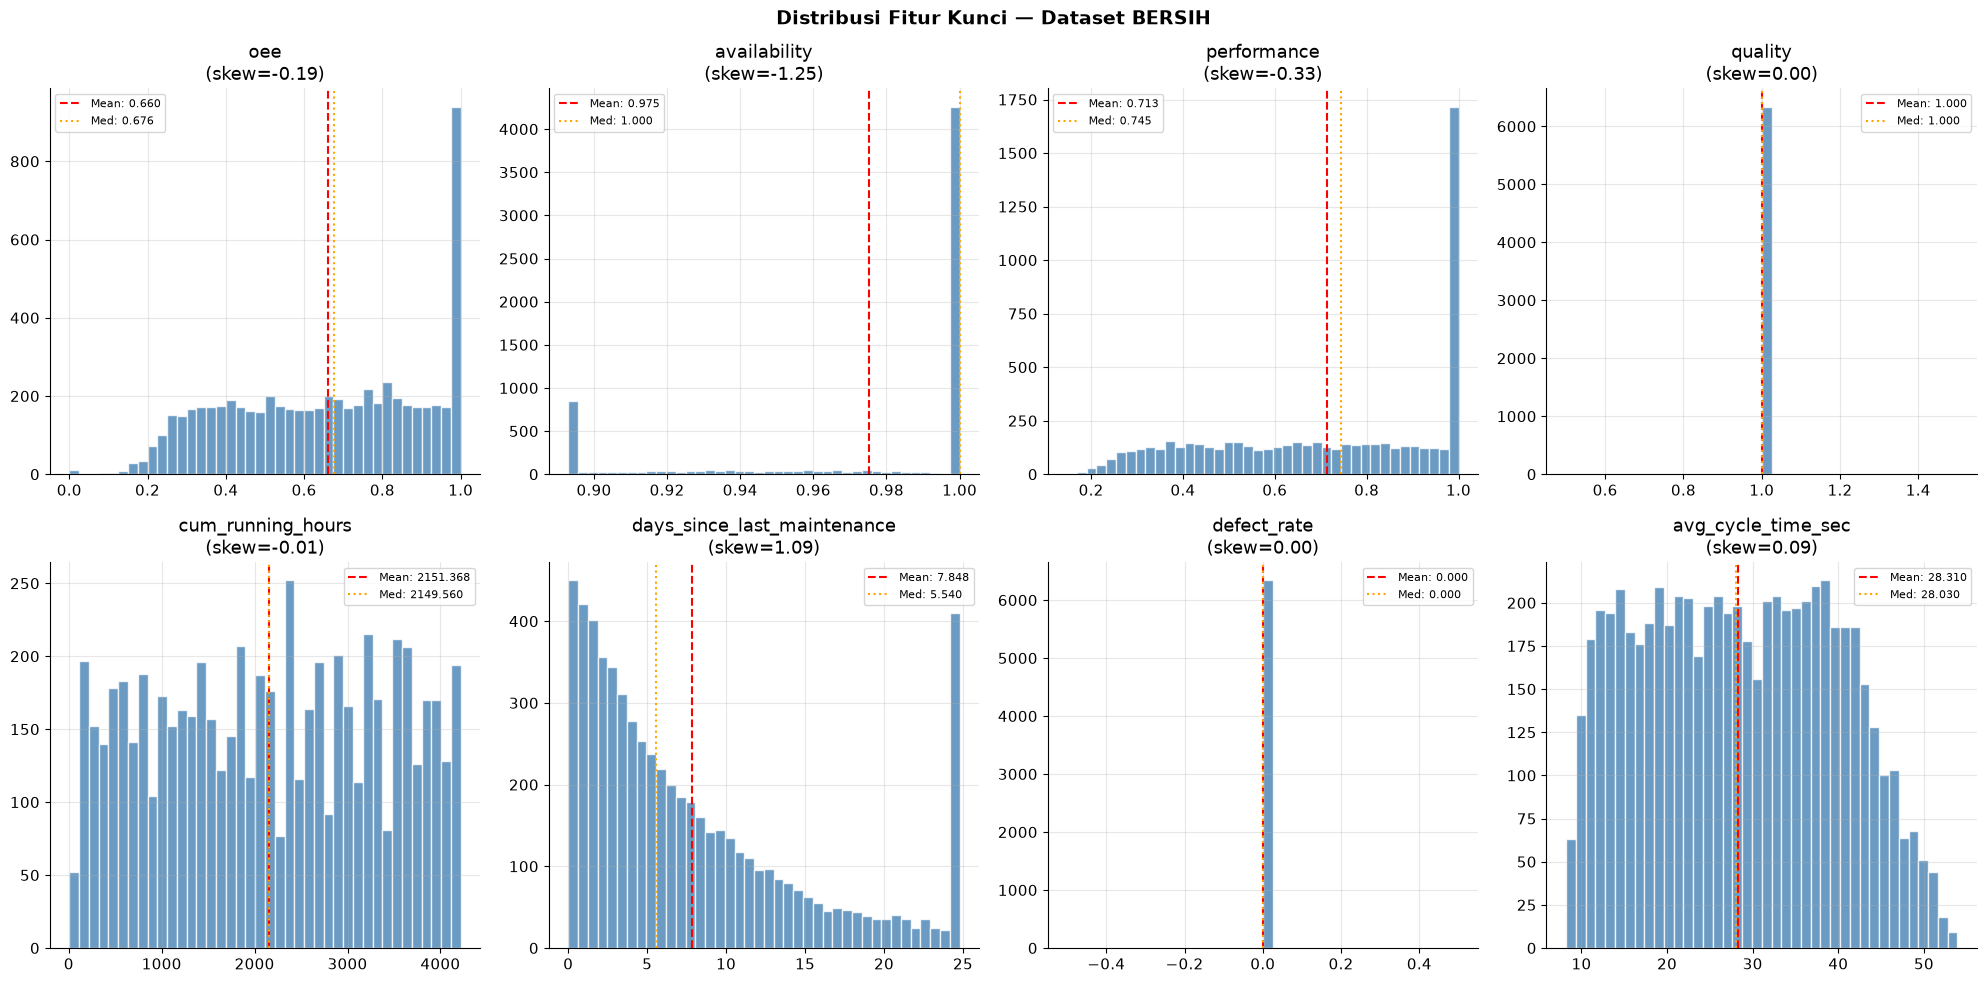

In [58]:
# Distribusi fitur kunci setelah cleaning
KEY_VIZ = [c for c in ['oee', 'availability', 'performance', 'quality',
                         'cum_running_hours', 'days_since_last_maintenance',
                         'defect_rate', 'avg_cycle_time_sec'] if c in df.columns]

n, cpr = len(KEY_VIZ), 4
fig, axes = plt.subplots((n+cpr-1)//cpr, cpr, figsize=(20, 5*((n+cpr-1)//cpr)))
axes = axes.flat

for ax, col in zip(axes, KEY_VIZ):
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  linewidth=1.5,
                label=f'Med: {data.median():.3f}')
    ax.set_title(f'{col}\n(skew={data.skew():.2f})')
    ax.legend(fontsize=8)

for ax in list(axes)[len(KEY_VIZ):]:
    ax.set_visible(False)

plt.suptitle('Distribusi Fitur Kunci — Dataset BERSIH', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚖️ 9. Laporan Class Imbalance

  CLASS IMBALANCE REPORT

[failure_binary]
  0 (No failure): 5,090 (80.3%)
  1 (Will fail) : 1,250 (19.7%)
  Imbalance ratio: 1 : 4.1
  ⚠️  Rekomendasi:
     • SMOTE (Synthetic Minority Oversampling) — sebelum training
     • class_weight="balanced" — di model sklearn
     • scale_pos_weight=4 — di XGBoost
     • Threshold tuning (ROC-AUC, PR-curve lebih baik dari Accuracy)

[risk_level_encoded]
  0 (No Risk     ): 5,090 (80.3%)
  1 (Low Risk    ): 256 (4.0%)
  2 (Medium Risk ): 296 (4.7%)
  3 (High Risk   ): 698 (11.0%)
  ⚠️  Rekomendasi:
     • class_weight="balanced" di RandomForest/LogisticRegression
     • SMOTE-NC untuk data campuran numerik+kategorikal
     • Macro F1-score & Confusion Matrix sebagai metrik evaluasi


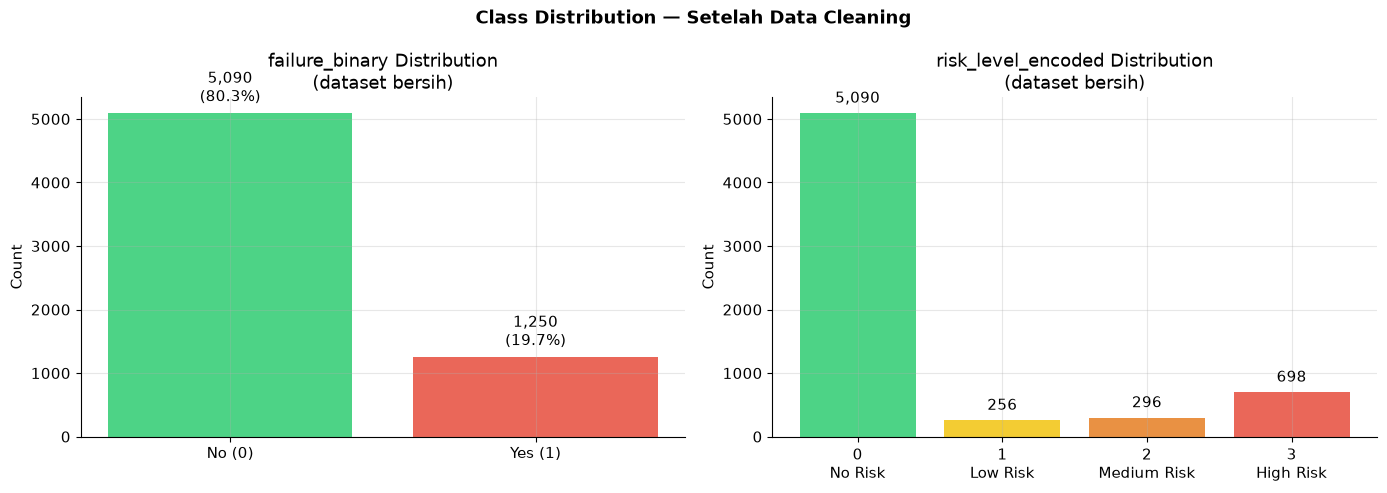

In [59]:
RISK_COLORS = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

print('=' * 60)
print('  CLASS IMBALANCE REPORT')
print('=' * 60)

# Binary
if 'failure_binary' in df.columns:
    vc = df['failure_binary'].value_counts().sort_index()
    n0, n1 = int(vc.get(0, 0)), int(vc.get(1, 0))
    ratio  = n0 / n1 if n1 else float('inf')
    print(f'\n[failure_binary]')
    print(f'  0 (No failure): {n0:,} ({n0/(n0+n1)*100:.1f}%)')
    print(f'  1 (Will fail) : {n1:,} ({n1/(n0+n1)*100:.1f}%)')
    print(f'  Imbalance ratio: 1 : {ratio:.1f}')
    print(f'  ⚠️  Rekomendasi:')
    print(f'     • SMOTE (Synthetic Minority Oversampling) — sebelum training')
    print(f'     • class_weight="balanced" — di model sklearn')
    print(f'     • scale_pos_weight={ratio:.0f} — di XGBoost')
    print(f'     • Threshold tuning (ROC-AUC, PR-curve lebih baik dari Accuracy)')

# Multi-class
if 'risk_level_encoded' in df.columns:
    vc_mc = df['risk_level_encoded'].value_counts().sort_index()
    print(f'\n[risk_level_encoded]')
    for i, risk in enumerate(RISK_ORDER):
        n = int(vc_mc.get(i, 0))
        print(f'  {i} ({risk:<12}): {n:,} ({n/len(df)*100:.1f}%)')
    print(f'  ⚠️  Rekomendasi:')
    print(f'     • class_weight="balanced" di RandomForest/LogisticRegression')
    print(f'     • SMOTE-NC untuk data campuran numerik+kategorikal')
    print(f'     • Macro F1-score & Confusion Matrix sebagai metrik evaluasi')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'failure_binary' in df.columns:
    vc = df['failure_binary'].value_counts().sort_index()
    bars = axes[0].bar(['No (0)', 'Yes (1)'], vc.values,
                        color=['#2ecc71', '#e74c3c'], alpha=0.85)
    axes[0].bar_label(bars, labels=[f'{v:,}\n({v/vc.sum()*100:.1f}%)' for v in vc.values], padding=5)
    axes[0].set_title('failure_binary Distribution\n(dataset bersih)')
    axes[0].set_ylabel('Count')

if 'risk_level_encoded' in df.columns:
    vc_mc = df['risk_level_encoded'].value_counts().sort_index()
    bars2 = axes[1].bar(
        [f'{i}\n{RISK_ORDER[i]}' for i in vc_mc.index],
        vc_mc.values, color=RISK_COLORS[:len(vc_mc)], alpha=0.85
    )
    axes[1].bar_label(bars2, labels=[f'{v:,}' for v in vc_mc.values], padding=5)
    axes[1].set_title('risk_level_encoded Distribution\n(dataset bersih)')
    axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution — Setelah Data Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 10. Simpan Dataset Bersih

In [60]:
# Definisikan kolom fitur (tanpa target)
ALL_TARGETS = ['failure_binary', 'risk_level_encoded', TARGET_REGRESSION,
               TARGET_BINARY, TARGET_MULTICLASS]
FEATURE_COLS = [c for c in df.columns if c not in ALL_TARGETS]

print('📋 Feature columns yang akan digunakan:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'   {i:>2}. {col}')
print(f'\nTotal fitur: {len(FEATURE_COLS)}')

📋 Feature columns yang akan digunakan:
    1. total_output
    2. avg_cycle_time_sec
    3. throughput_units_per_hour
    4. shift_total_pass
    5. operating_seconds
    6. oee
    7. availability
    8. performance
    9. quality
   10. total_produced
   11. total_pass
   12. total_reject
   13. defect_rate
   14. cum_running_hours
   15. days_since_last_maintenance
   16. corrective_wo_last_7d
   17. preventive_wo_last_30d
   18. hour_of_day
   19. day_of_week
   20. week_of_year
   21. month
   22. is_weekend
   23. is_night_shift
   24. machine_encoded
   25. line_encoded

Total fitur: 25


In [61]:
# ── Simpan semua versi ────────────────────────────────────────────────────────
OUTPUT_DIR = PROCESSED_DIR

# 1. Dataset lengkap bersih
path_full = OUTPUT_DIR / 'pm_cleaned_full.csv'
df.to_csv(path_full, index=False)
print(f'✅ Full cleaned dataset   : {path_full.name}  {df.shape}')

# 2. Binary Classification (failure_next_24h)
df_bin = df[FEATURE_COLS + ['failure_binary']].dropna()
path_bin = OUTPUT_DIR / 'pm_cleaned_binary.csv'
df_bin.to_csv(path_bin, index=False)
print(f'✅ Binary Classification  : {path_bin.name}  {df_bin.shape}')
print(f'   Class 0: {(df_bin["failure_binary"]==0).sum():,}  |  Class 1: {(df_bin["failure_binary"]==1).sum():,}')

# 3. Multi-class Classification (maintenance_risk_level)
df_mc = df[FEATURE_COLS + ['risk_level_encoded']].dropna()
path_mc = OUTPUT_DIR / 'pm_cleaned_multiclass.csv'
df_mc.to_csv(path_mc, index=False)
print(f'\n✅ Multi-class Classification: {path_mc.name}  {df_mc.shape}')
for i, risk in enumerate(RISK_ORDER):
    n = (df_mc['risk_level_encoded'] == i).sum()
    print(f'   Class {i} ({risk:<12}): {n:,}')

# 4. Regression (hours_to_next_failure_event)
if TARGET_REGRESSION in df.columns:
    df_reg = df[FEATURE_COLS + [TARGET_REGRESSION]].dropna(subset=[TARGET_REGRESSION])
    path_reg = OUTPUT_DIR / 'pm_cleaned_regression.csv'
    df_reg.to_csv(path_reg, index=False)
    print(f'\n✅ Regression              : {path_reg.name}  {df_reg.shape}')
    print(f'   hours_to_next_failure: {df_reg[TARGET_REGRESSION].describe()[["min","mean","max"]].round(1).to_dict()}')

print(f'\n📂 Semua file tersimpan di: {OUTPUT_DIR}')

✅ Full cleaned dataset   : pm_cleaned_full.csv  (6340, 28)
✅ Binary Classification  : pm_cleaned_binary.csv  (6076, 26)
   Class 0: 4,880  |  Class 1: 1,196

✅ Multi-class Classification: pm_cleaned_multiclass.csv  (6076, 26)
   Class 0 (No Risk     ): 4,880
   Class 1 (Low Risk    ): 254
   Class 2 (Medium Risk ): 291
   Class 3 (High Risk   ): 651

✅ Regression              : pm_cleaned_regression.csv  (6217, 26)
   hours_to_next_failure: {'min': 0.0, 'mean': 111.9, 'max': 788.3}

📂 Semua file tersimpan di: c:\AI\AI untuk Dashboard TA\New folder\dataset\processed


In [62]:
# ── Simpan Laporan Cleaning ───────────────────────────────────────────────────
report = {
    'timestamp'       : datetime.now().isoformat(),
    'input_file'      : str(INPUT_FILE),
    'shape_before'    : {'rows': ORIGINAL_SHAPE[0], 'cols': ORIGINAL_SHAPE[1]},
    'shape_after'     : {'rows': df.shape[0],        'cols': df.shape[1]},
    'rows_removed'    : ORIGINAL_SHAPE[0] - df.shape[0],
    'cols_removed'    : ORIGINAL_SHAPE[1] - df.shape[1],
    'cleaning_steps'  : cleaning_log,
    'imputation'      : imputation_report,
    'winsorizing'     : winsor_log,
    'encode_mapping'  : {k: {str(kk): vv for kk, vv in v.items()} for k, v in encode_log.items()},
    'feature_cols'    : FEATURE_COLS,
    'target_cols'     : {'binary': 'failure_binary', 'multiclass': 'risk_level_encoded',
                          'regression': TARGET_REGRESSION},
    'class_imbalance' : {
        'binary_ratio'   : round(n0/n1, 2) if 'n1' in dir() and n1 else None,
        'recommendation' : ['SMOTE', 'class_weight=balanced', 'scale_pos_weight for XGBoost'],
    },
    'validation'      : checks,
    'output_files'    : [
        str(path_full), str(path_bin), str(path_mc),
        str(path_reg) if TARGET_REGRESSION in df.columns else None,
    ],
}

report_path = OUTPUT_DIR / 'pm_cleaning_report.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, default=str)

print(f'✅ Laporan tersimpan: {report_path}')

# List all PM files
print('\n📂 Semua file Predictive Maintenance di processed/:')
for f in sorted(OUTPUT_DIR.iterdir()):
    if 'pm_' in f.name or 'predictive' in f.name:
        sz = f.stat().st_size / 1024
        print(f'   📄 {f.name:<55} {sz:>8.1f} KB')

✅ Laporan tersimpan: c:\AI\AI untuk Dashboard TA\New folder\dataset\processed\pm_cleaning_report.json

📂 Semua file Predictive Maintenance di processed/:
   📄 pm_binary_classification.csv                               492.4 KB
   📄 pm_cleaned_binary.csv                                      616.7 KB
   📄 pm_cleaned_full.csv                                        692.0 KB
   📄 pm_cleaned_multiclass.csv                                  616.7 KB
   📄 pm_cleaned_regression.csv                                  654.9 KB
   📄 pm_cleaning_report.json                                      6.8 KB
   📄 pm_multiclass_classification.csv                           523.2 KB
   📄 pm_regression_hours_to_failure.csv                         500.6 KB
   📄 predictive_maintenance_raw.csv                            2118.1 KB


In [63]:
print('=' * 70)
print('  RINGKASAN DATA CLEANING — PREDICTIVE MAINTENANCE DATASET')
print('=' * 70)
print(f'''
📌 HASIL CLEANING
  Shape awal    : {ORIGINAL_SHAPE[0]:,} rows × {ORIGINAL_SHAPE[1]} kolom
  Shape bersih  : {df.shape[0]:,} rows × {df.shape[1]} kolom
  Baris dihapus : {ORIGINAL_SHAPE[0]-df.shape[0]:,}
  Kolom dihapus : {ORIGINAL_SHAPE[1]-df.shape[1]} (ID/UUID)
  Fitur baru    : +6 fitur temporal (hour, day, week, month, weekend, night)

📌 TAHAPAN YANG DILAKUKAN
  1. Drop ID columns   → {len(drop_reasons)} kolom ID/UUID dihapus
  2. Fitur temporal    → 6 fitur diekstrak dari timestamp
  3. Encoding          → machine_name, line_name → integer
  4. Target encoding   → failure_binary (0/1), risk_level_encoded (0-3)
  5. Missing values    → imputasi median per mesin, recalculate defect_rate
  6. Duplikasi         → {ORIGINAL_SHAPE[0]-df.shape[0]:,} baris dihapus
  7. Outlier           → Winsorizing pada {len(winsor_log)} kolom
  8. Range logis       → Clip OEE/rate [0,1], operating_seconds [0,28800]
  9. Konsistensi       → Recalculate defect_rate, validasi OEE formula

📌 OUTPUT FILES
  • pm_cleaned_full.csv        → Semua fitur + semua target ({df.shape})
  • pm_cleaned_binary.csv      → Siap training Binary Classification
  • pm_cleaned_multiclass.csv  → Siap training Multi-class Classification
  • pm_cleaned_regression.csv  → Siap training Regression (hours to failure)
  • pm_cleaning_report.json    → Laporan lengkap

📌 ENCODE MAPPING
  failure_binary       : No→0, Yes→1
  risk_level_encoded   : No Risk→0, Low Risk→1, Medium Risk→2, High Risk→3

📌 LANGKAH SELANJUTNYA → MODEL TRAINING
  1. Train-Test Split (stratified 80/20)
  2. Feature Scaling (StandardScaler / RobustScaler)
  3. Handle Imbalance → SMOTE / class_weight
  4. Train Binary Model → XGBoost / RandomForest / LightGBM
  5. Train Multi-class Model → XGBoost / RandomForest
  6. Evaluasi → ROC-AUC, F1-Macro, Confusion Matrix
''')
print('=' * 70)
print('  ✅ DATA CLEANING SELESAI — SIAP TRAINING AI MODEL!')
print('=' * 70)

  RINGKASAN DATA CLEANING — PREDICTIVE MAINTENANCE DATASET

📌 HASIL CLEANING
  Shape awal    : 6,340 rows × 29 kolom
  Shape bersih  : 6,340 rows × 28 kolom
  Baris dihapus : 0
  Kolom dihapus : 1 (ID/UUID)
  Fitur baru    : +6 fitur temporal (hour, day, week, month, weekend, night)

📌 TAHAPAN YANG DILAKUKAN
  1. Drop ID columns   → 5 kolom ID/UUID dihapus
  2. Fitur temporal    → 6 fitur diekstrak dari timestamp
  3. Encoding          → machine_name, line_name → integer
  4. Target encoding   → failure_binary (0/1), risk_level_encoded (0-3)
  5. Missing values    → imputasi median per mesin, recalculate defect_rate
  6. Duplikasi         → 0 baris dihapus
  7. Outlier           → Winsorizing pada 10 kolom
  8. Range logis       → Clip OEE/rate [0,1], operating_seconds [0,28800]
  9. Konsistensi       → Recalculate defect_rate, validasi OEE formula

📌 OUTPUT FILES
  • pm_cleaned_full.csv        → Semua fitur + semua target ((6340, 28))
  • pm_cleaned_binary.csv      → Siap training Bin